# Quantum signal processing (Aula 4)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.compiler import transpile

Um circuito QSP para um único qubit.

A sequência segue a convenção:
\begin{equation}
U = e^{i \phi_0 Z} \prod_{k=1}^{d} ( R_x(\theta)  e^{i \phi_k Z} ).
\end{equation}

Dados:

Lista de ângulos de fase $[\phi_0, \phi_1, \ldots , \phi_d]$.

O valor do ''sinal'' (codifica $x$). Normalmente $x = \cos(\theta/2)$.

## Circuito

Calculando QSP para 200 pontos...


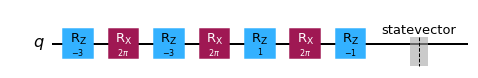

In [2]:
def build_qsp_circuit(phi_phases, theta_input):
 
    qc = QuantumCircuit(1)
    
    # 1. Primeira rotação de fase (phi_0)
    qc.rz(-2 * phi_phases[0], 0)
    
    # 2. Repita o processo nas fases restantes, intercalando o operador de sinal. R_x(theta)
    for phi in phi_phases[1:]:
        qc.rx(theta_input, 0)       # Operador da sinal W(x)
        qc.rz(-2 * phi, 0)          # Processamento da sinal (Phase Rotation)
        
    qc.save_statevector() #
    return qc


# 1. Definimos fases de exemplo.
# Essas fases geram um polinômio específico (um exemplo arbitrário de grau 3).
#phis = [0.5, 1.5, -1.5, 0.5] 
phis = [1.5, 1.5, -0.5, 0.5] 


# 2. Definimos o intervalo de entrada 'x'
# No QSP padrão para 1 qubit: x = cos(theta / 2).
# Variamos theta de 0 a 2π para ver a resposta completa.
theta_values = np.linspace(0, 2 * np.pi, 200)
x_values = np.cos(theta_values / 2) # Variável polinomial efetiva
probs_0 = []

simulator = AerSimulator()

#
print(f"Calculando QSP para {len(theta_values)} pontos...")

for theta in theta_values:
    # 
    qc = build_qsp_circuit(phis, theta)
    
    # 
    qc_transpiled = transpile(qc, simulator)
    job = simulator.run(qc_transpiled)
    result = job.result()
    
    # 
    statevector = result.get_statevector(qc)
    
    prob_0 = np.abs(statevector[0])**2
    probs_0.append(prob_0)

qc.draw('mpl')

## Resultados

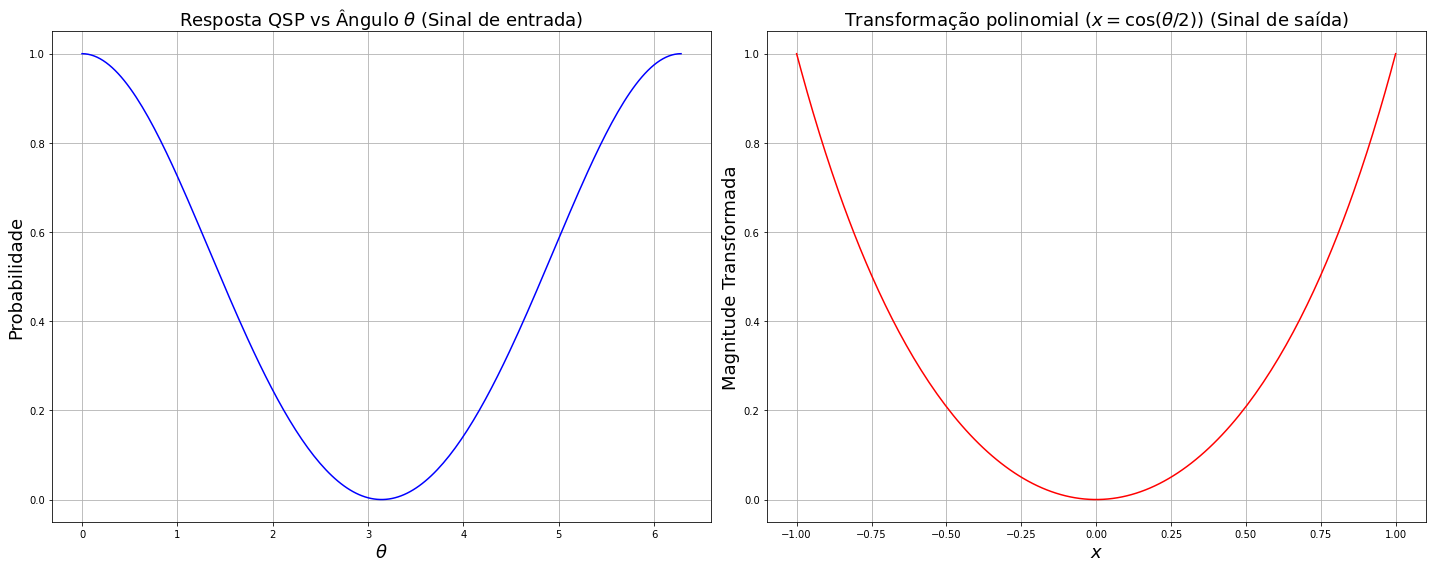

In [3]:
plt.figure(figsize=(20, 8))

# Figura 1: Probabilidade vs Theta 
plt.subplot(1, 2, 1)
plt.plot(theta_values, probs_0, color='blue')
plt.title(r'Resposta QSP vs Ângulo $\theta$ (Sinal de entrada)', fontsize = 18)
plt.xlabel(r'$\theta$', fontsize = 18)
plt.ylabel('Probabilidade', fontsize = 18)
plt.grid(True)

# Figura 2: Probabilidade vs x (Dominio polinomial)
# x = cos(theta/2)
plt.subplot(1, 2, 2)
plt.plot(x_values, probs_0, color='red')
plt.title(r'Transformação polinomial ($x = \cos(\theta/2)$) (Sinal de saída)', fontsize = 18)
plt.xlabel(r'$x$', fontsize = 18)
plt.ylabel('Magnitude Transformada', fontsize = 18)
plt.grid(True)

plt.tight_layout()
plt.show()

## Algoritmo de Trotter - Suzuki

O algoritmo de Trotter-Suzuki (frequentemente chamado apenas de Trotter) é uma ferramenta fundamental na simulação quântica, especialmente quando queremos simular a evolução temporal de um sistema descrito por um Hamiltoniano complexo (o operador de energia total).

Algoritmo de Trotter (Conceitual):

Se o seu Hamiltoniano fosse $\hat{H}=\hat{H}_1+\hat{H}_2$, o operador de evolução temporal $e^{−i(\hat{H}_1+\hat{H}_2)t}$ pode ser aproximado para pequenos $\delta t$ como:
\begin{equation}
e^{−i(\hat{H}_1+\hat{H}_2)δt} \approx e^{−i\hat{H}_1 \delta t} e^{-i\hat{H}_2 \delta t}
\end{equation}

Para um tempo total $t=N \delta t$, a evolução seria aproximada por:
\begin{equation}
e^{−i(\hat{H}_1+\hat{H}_2)t} \approx (e^{−i\hat{H}_1 \delta t} e^{−i\hat{H}_2 \delta t})^N
\end{equation}

Cada um dos operadores $e^{−i\hat{H}_1 \delta t}$ e $e^{−i\hat{H}_2 \delta t}$ seria implementado como uma sequência de portas quânticas.